**Hands-on 1 — Simple Linear Regression (SLR) con Python**

**Fundamentos de la técnica SLR**

La Regresión Lineal es una técnica de aprendizaje supervisado utilizada para predecir el valor de una variable a partir de una o más variables relacionadas con ella. A la variable que se desea predecir se le llama variable dependiente (y), y a las variables que se usan para hacer la predicción se les llama variables independientes (x).

Cuando el modelo utiliza una sola variable independiente, la técnica se llama Regresión Lineal Simple (Simple Linear Regression, SLR). Cuando utiliza dos o más variables independientes, se le llama Regresión Lineal Múltiple.

En SLR, los datos se representan como un conjunto de pares entrada-salida (xᵢ, yᵢ), donde:

xᵢ es el i-ésimo valor de entrada (un escalar, ya que solo hay una variable independiente).
yᵢ es el i-ésimo valor de salida real (también un escalar).
El objetivo de la técnica es encontrar la línea recta que mejor describe la relación entre x e y, de manera que, dado un nuevo valor de x, se pueda estimar un valor de y con la menor cantidad de error posible.

**Modelo matemático**

La recta que representa la relación entre la variable independiente y la variable dependiente se expresa como:

y_pred = w·x + b

Donde:

w es la pendiente de la recta (también llamada peso).
b es la ordenada al origen (también llamada sesgo o intercepto).
Para un valor de entrada específico xᵢ, la salida estimada se calcula como:

y_pred(i) = w·xᵢ + b

Para medir qué tan buena es la recta obtenida, se necesita una función de pérdida que compare los valores predichos contra los valores reales. La más usada en SLR es el Error Cuadrático Medio (Mean Squared Error, MSE):

MSE = (1/n) · Σ (y_pred(i) − y_true(i))²

Sustituyendo y_pred(i) = w·xᵢ + b, el MSE queda en función de los parámetros del modelo:

MSE = (1/n) · Σ (w·xᵢ + b − y_true(i))²

Entrenar el modelo consiste en encontrar los valores de w y b que minimizan este error.

Una notación equivalente, usada más adelante junto con scikit-learn, expresa la misma recta como una función de hipótesis:

ŷ = β₀ + β₁·x

Donde:

ŷ es la salida estimada por el modelo.
x es la variable independiente (entrada).
β₀ es el intercepto (equivalente a b): el punto donde la recta cruza el eje y. Aumentarlo desplaza toda la recta hacia arriba; disminuirlo la desplaza hacia abajo.
β₁ es la pendiente (equivalente a w): controla la inclinación de la recta. Un valor mayor la hace más pronunciada; un valor menor la hace más plana.
β₀ y β₁ son los parámetros que el modelo debe aprender durante el entrenamiento.

**Paso 1: Importación de librerías**

Antes de trabajar con los datos, se importan las dos librerías básicas para manipulación de datos y cálculo numérico:

import pandas as pd: importa la librería pandas, usada para leer y manipular datos en forma de tablas (DataFrames), y la renombra con el alias pd para escribir menos código al usarla.
import numpy as np: importa NumPy, la librería para operaciones numéricas y arreglos multidimensionales, con el alias np.

In [17]:
import pandas as pd
import numpy as np

**Paso 2: Carga del dataset**

El dataset utilizado (Advertising) contiene el presupuesto de publicidad invertido en TV, radio y periódico para distintos mercados, junto con las ventas (Sales) obtenidas en cada uno. La variable objetivo (que se quiere predecir) son las ventas, ya que es una variable continua.

df = pd.read_csv('Datasets/Advertising.csv'): usa la función read_csv de pandas para leer el archivo CSV indicado en la ruta y cargarlo como un DataFrame llamado df.
df = df.iloc[:, 1:]: usa .iloc (indexado por posición) para seleccionar todas las filas (:) y todas las columnas a partir de la segunda (1:), eliminando así la primera columna del DataFrame (el comentario del propio código indica que su propósito es quitar esa primera columna).
df.head(): muestra las primeras 5 filas del DataFrame, útil para inspeccionar rápidamente los datos cargados.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Advertising.csv') # Asegúrate de que esta sea la ruta correcta a tu archivo

# remove the first column from the DataFrame.
df = df.iloc[:, 1:]

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


**Paso 3: Selección de una característica (feature)**

Como SLR utiliza únicamente una variable independiente, del DataFrame completo se seleccionan solo dos columnas: la variable de entrada elegida (TV) y la variable de salida (Sales).

df_new = df[['TV', 'Sales']]: crea un nuevo DataFrame llamado df_new que contiene únicamente las columnas 'TV' y 'Sales' del DataFrame original df (se usa doble corchete porque se está pasando una lista de nombres de columnas).
df_new.head(): muestra las primeras 5 filas de este nuevo DataFrame reducido.

In [20]:
df_new = df[['TV', 'Sales']]
df_new.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


La siguiente línea confirma el tipo de objeto que es df_new:

type(df_new): la función type() devuelve la clase del objeto pasado como argumento; en este caso confirma que df_new sigue siendo un pandas.core.frame.DataFrame.

In [21]:
type(df_new) # pandas.core.frame.DataFrame

pandas.core.frame.DataFrame

**Paso 4: Conversión a arreglo de NumPy**

Para poder trabajar con operaciones numéricas puras (fuera de la estructura de un DataFrame), los datos se convierten a un arreglo de NumPy.

dataset = np.array(df): usa np.array() para convertir el DataFrame df en un arreglo (ndarray) de NumPy, guardado en la variable dataset.

In [22]:
dataset = np.array(df)

**Paso 5: División en entrenamiento y prueba (Train/Test Split)**

Antes de entrenar el modelo, los datos se separan en un conjunto de entrenamiento y uno de prueba, para poder evaluar después qué tan bien generaliza el modelo a datos que no vio durante el entrenamiento.

x = dataset[:, 0]: toma todas las filas (:) de la columna en la posición 0 del arreglo dataset y la asigna a x (variable independiente); el propio comentario del código indica este propósito.
y = dataset[:, 1]: toma todas las filas de la columna en la posición 1 y la asigna a y (variable dependiente).
from sklearn.model_selection import train_test_split: importa la función train_test_split desde el módulo model_selection de scikit-learn, usada para dividir datos en subconjuntos de entrenamiento y prueba.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42): divide los arreglos x y y en cuatro partes: x_train/y_train (datos de entrenamiento) y x_test/y_test (datos de prueba). El parámetro test_size=0.2 indica que el 20% de los datos se reserva para prueba (y por lo tanto 80% para entrenamiento); random_state=42 fija la semilla aleatoria para que la división sea reproducible cada vez que se ejecute el código.
Las cuatro líneas print(...) imprimen el atributo .shape (las dimensiones) de cada arreglo resultante, para verificar cuántos elementos quedaron en cada subconjunto; los comentarios muestran la forma esperada de salida.

In [23]:
# Extract the values from array in the first column, assign them to the variable 'x'.
x = dataset[:, 0]
y = dataset[:, 1]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape) # (160,)
print(y_train.shape) # (160,)
print(x_test.shape)  # (40,)
print(y_test.shape)  # (40,)

(160,)
(160,)
(40,)
(40,)


**Paso 6: Visualización de los datos de entrenamiento**

Antes de entrenar el modelo, es útil visualizar cómo se distribuyen los datos de entrenamiento.

import matplotlib.pyplot as plt: importa el módulo pyplot de la librería Matplotlib, usado para crear gráficas, con el alias plt.
plt.scatter(x_train, y_train);: genera un diagrama de dispersión (scatter plot) colocando x_train en el eje horizontal y y_train en el eje vertical; el punto y coma al final evita que Jupyter/Colab imprima automáticamente el objeto que devuelve la función.

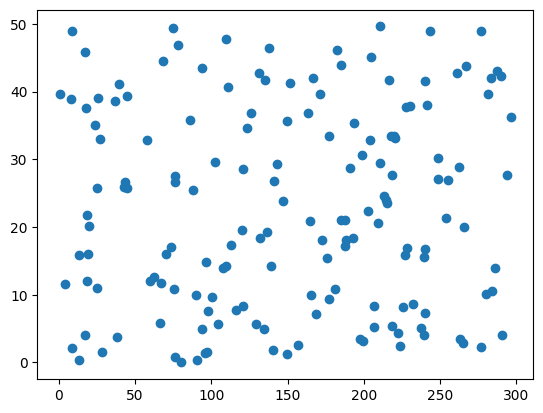

In [24]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train);

**Función de hipótesis (Hypothesis function)**

Cuando solo se tiene una variable de entrada (caso univariado), la fórmula de la recta —también llamada función de hipótesis— se simplifica a:

ŷ = β₀ + β₁·x

Esta es la misma expresión presentada en la sección de Modelo matemático, y es la función que el modelo de scikit-learn ajustará automáticamente en el siguiente paso, encontrando los valores óptimos de β₀ (intercepto) y β₁ (pendiente).

 **Paso 7: Ajuste de forma (reshape) y entrenamiento del modelo**

Scikit-learn espera que los datos de entrada tengan una forma bidimensional (matriz de n_muestras × n_características), aunque solo haya una característica. Por eso es necesario cambiar la forma de los arreglos antes de entrenar.

x_train = x_train.reshape(-1, 1): usa .reshape() para convertir el arreglo unidimensional x_train en un arreglo bidimensional con una sola columna; el -1 indica a NumPy que calcule automáticamente el número de filas necesario para conservar todos los elementos.
y_train = y_train.reshape(-1, 1): aplica la misma transformación al arreglo y_train.

In [25]:
x_train = x_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)

La siguiente línea permite verificar el resultado del reshape:

x_train.shape, y_train.shape: devuelve, como una tupla, la forma de ambos arreglos después de la transformación; el comentario muestra la salida esperada.

In [26]:
x_train.shape, y_train.shape
# ((160, 1), (160, 1))

((160, 1), (160, 1))

Ahora sí se entrena el modelo:

from sklearn.linear_model import LinearRegression: importa la clase LinearRegression desde el módulo linear_model de scikit-learn; esta clase implementa el algoritmo de regresión lineal (mínimos cuadrados ordinarios).
model = LinearRegression(): crea una instancia (objeto) de la clase LinearRegression, guardada en la variable model, usando sus valores por defecto.
model.fit(x_train, y_train): llama al método .fit(), que entrena el modelo con los datos de entrada x_train y las salidas reales y_train; internamente, scikit-learn calcula los valores de β₀ y β₁ que minimizan el MSE sobre esos datos.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Una vez entrenado, se pueden consultar los parámetros que el modelo aprendió:

model.coef_: atributo del modelo entrenado que contiene el/los coeficiente(s) o pendiente(s) aprendidas (equivalente a β₁).
model.intercept_: atributo que contiene el intercepto aprendido (equivalente a β₀).

In [28]:
model.coef_, model.intercept_
# 0.04652973, 7.11963843

(array([[0.00944804]]), array([21.4582361]))

**Cálculo de la pérdida del modelo entrenado**

Con el modelo ya entrenado, se puede calcular qué tan grande es el error sobre los propios datos de entrenamiento, usando la fórmula de MSE vista en la sección de Modelo matemático.

y_pred = model.predict(x_train): usa el método .predict() del modelo entrenado para generar las predicciones correspondientes a x_train, guardándolas en y_pred.
loss = np.mean((y_train - y_pred) ** 2): calcula manualmente el MSE: resta las predicciones de los valores reales, eleva cada diferencia al cuadrado con ** 2, y obtiene el promedio de esos cuadrados con np.mean().
print(loss): imprime el valor numérico de la pérdida obtenida; el comentario muestra el valor esperado.

In [29]:
# Compute the predicted values
y_pred = model.predict(x_train)

# Compute the loss (mean squared error)
loss = np.mean((y_train - y_pred) ** 2)
print(loss)  # 10.60

217.19229029770887


**Paso 8: Graficar la función de hipótesis con los parámetros calculados**

Por último, se dibuja la recta obtenida por el modelo sobre los datos originales, para visualizar qué tan bien se ajusta.

plt.scatter(x_train, y_train);: vuelve a dibujar el diagrama de dispersión de los datos de entrenamiento, como base sobre la cual se trazará la recta.
x = np.linspace(0, 300, 100): genera 100 valores igualmente espaciados entre 0 y 300, que se usarán como el rango del eje x para dibujar la recta.
b0 = 7.11: define manualmente el valor del intercepto (una versión redondeada del model.intercept_ obtenido antes).
b1 = 0.04: define manualmente el valor de la pendiente (una versión redondeada del model.coef_ obtenido antes).
y_hat = b0 + b1*x: calcula los valores de la recta (función de hipótesis) para cada valor de x, usando la fórmula ŷ = β₀ + β₁·x.
plt.plot(x, y_hat, 'r', label=f'b0 = {b0}, b1 = {b1}');: dibuja la recta y_hat contra x en color rojo ('r'); el parámetro label usa un f-string para construir dinámicamente el texto de la etiqueta con los valores actuales de b0 y b1.
plt.legend(): muestra el cuadro de leyenda en la gráfica, con la etiqueta definida en el paso anterior.

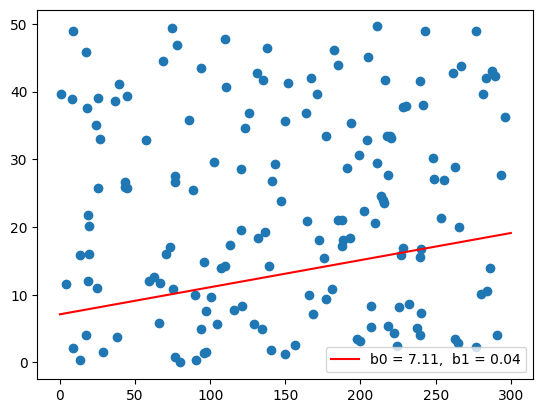

In [30]:
plt.scatter(x_train, y_train);

x = np.linspace(0, 300, 100)

b0 = 7.11
b1 = 0.04

y_hat = b0 + b1*x

plt.plot(x, y_hat, 'r',  label=f'b0 = {b0},  b1 = {b1}');
plt.legend()